In [1]:
!pip install langchain langchain_community

In [2]:
!pip install langchain-groq
from langchain_groq import ChatGroq

In [ ]:
GROQ_API_KEY = "YOUR_GROQ_API_KEY"  # Replace with your actual API key

llm = ChatGroq( 
    model="openai/gpt-oss-120b",
    api_key=GROQ_API_KEY,
)

In [19]:
from langgraph.graph import START,END,StateGraph
from typing import TypedDict
from langgraph.checkpoint.memory import MemorySaver

In [20]:
from typing import TypedDict, Optional

class State(TypedDict):
  document:str
  summary:Optional[str]
  sentiment:Optional[str]
  key_entites:Optional[str]
  final_text: Optional[str]

In [21]:
def summary(state:State):
  response=llm.invoke(f" Summarize the document {state['document']}")
  return {"summary":response.content}

In [22]:
def sentiment(state:State):
  response=llm.invoke(f" What is the sentiment of the document {state['document']}")
  return {"sentiment":response.content}

In [23]:
def key_entites(state:State):
  response=llm.invoke(f" What are the key entities in the document {state['document']}")
  return {"key_entites":response.content}

In [24]:
def final_answer(state:State):
  formatted_string = f"Summary: {state['summary']}\nSentiment: {state['sentiment']}\nKey Entities: {state['key_entites']}"
  return {"final_text": formatted_string}

In [25]:
builder=StateGraph(State)
builder.add_node("summary",summary)
builder.add_node("sentiment",sentiment)
builder.add_node("key_entites",key_entites)
builder.add_node("final_answer",final_answer)

In [26]:
builder.add_edge(START,"summary")
builder.add_edge(START,"sentiment")
builder.add_edge(START,"key_entites")
builder.add_edge("summary","final_answer")
builder.add_edge("sentiment","final_answer")
builder.add_edge("key_entites","final_answer")
builder.add_edge("final_answer",END)

In [27]:
memory=MemorySaver()

In [28]:
graph=builder.compile(checkpointer=memory)

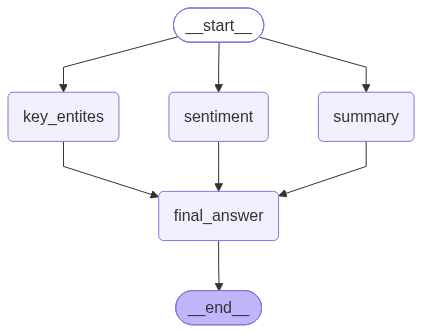

In [29]:
from IPython.display import Image, display

# Render and display the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
documents="""
    ## 🤖 What is AI (Artificial Intelligence)?

    **Artificial Intelligence (AI)** is a branch of computer science that focuses on creating **machines and computer systems capable of performing tasks that normally require human intelligence**.

    In simple words, **AI makes computers capable of learning from information, understanding patterns, solving problems, making decisions, and interacting with humans.**

    ### 🧠 What can AI do?

    AI systems can perform many intelligent tasks, including:

    1. **Learning** - AI can learn patterns from data.
    2. **Reasoning** - AI can analyze information and reach conclusions.
    3. **Problem-solving** - AI can find solutions to complex problems.
    4. **Natural Language Processing (NLP)** - AI can understand and generate human language.
    5. **Computer Vision** - AI can analyze images and videos.
    6. **Speech Recognition** - AI can convert spoken language into text or understand speech.
    7. **Prediction** - AI can use historical data to predict future outcomes.
    8. **Decision-making** - AI can select an appropriate action based on available information.
"""

In [31]:
config={
    "configurable":{
        "thread_id":"chan_chat"
    }
}

result=graph.invoke({
    "document":documents
}, config=config)

In [32]:
print(result['final_text'])

Summary: **Summary – What is AI (Artificial Intelligence)**  

- **Definition:** AI is a branch of computer science that builds machines and software that can perform tasks normally requiring human intelligence—learning, pattern recognition, problem‑solving, decision‑making, and human interaction.  

- **Core Capabilities:**  
  1. **Learning** – extracting patterns from data.  
  2. **Reasoning** – analyzing information to draw conclusions.  
  3. **Problem‑solving** – finding solutions to complex challenges.  
  4. **Natural Language Processing (NLP)** – understanding and generating human language.  
  5. **Computer Vision** – interpreting images and video.  
  6. **Speech Recognition** – converting or comprehending spoken language.  
  7. **Prediction** – forecasting future outcomes from historical data.  
  8. **Decision‑making** – selecting appropriate actions based on available information.  

In short, AI enables computers to learn from data, understand and act on that knowledge